# 04 ResNet18 Model

ResNet18 adapted for grayscale handwritten Chinese character recognition.


In [1]:
from google.colab import drive

# Mount Google Drive to access dataset files and save experiment results
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Libraries


In [2]:
import json
import pickle
import time
import copy
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tqdm import tqdm

## Load Metadata and Cross-Validation Folds


In [3]:
METADATA_PATH = Path("/content/drive/MyDrive/Diploma/CASIA_246_metadata.json")
FOLDS_PATH = Path("/content/drive/MyDrive/Diploma/CASIA_246_5folds.pkl")

with open(METADATA_PATH, "r", encoding="utf-8") as file:
    metadata = json.load(file)

with open(FOLDS_PATH, "rb") as file:
    folds = pickle.load(file)

NUM_CLASSES = metadata["number_of_classes"]
IMAGE_SIZE = metadata.get("image_size", 64)
BATCH_SIZE = metadata.get("batch_size", 64)

class_to_idx = metadata["class_to_idx"]
idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}

print("Number of classes:", NUM_CLASSES)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of folds:", len(folds))

Number of classes: 246
Image size: 64
Batch size: 64
Number of folds: 5


## Dataset Paths and Optional Extraction


In [4]:
ZIP_PATH = Path("/content/drive/MyDrive/Diploma/CASIA_246.zip")

DATASET_DIR = Path("/content/CASIA_246")
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

def fix_zip_filename(filename):
    # Fix filenames stored as UTF-8 but read as cp437
    try:
        return filename.encode("cp437").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return filename

if not DATASET_DIR.exists():
    print("Dataset folder was not found. Extracting archive...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        for file_info in zip_ref.infolist():
            fixed_name = fix_zip_filename(file_info.filename)
            target_path = Path("/content") / fixed_name

            if file_info.is_dir():
                target_path.mkdir(parents=True, exist_ok=True)
            else:
                target_path.parent.mkdir(parents=True, exist_ok=True)

                with zip_ref.open(file_info) as source:
                    with open(target_path, "wb") as target:
                        target.write(source.read())

    print("Dataset extracted.")
else:
    print("Dataset already exists.")

assert TRAIN_DIR.exists(), f"Train folder not found: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Test folder not found: {TEST_DIR}"

print("Dataset directory:", DATASET_DIR)
print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)


Dataset already exists.
Dataset directory: /content/CASIA_246
Train directory: /content/CASIA_246/train
Test directory: /content/CASIA_246/test


## Define Image Transformations


In [5]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Light augmentation keeps handwritten character shapes readable
    transforms.RandomRotation(degrees=5, fill=255),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.04, 0.04),
        scale=(0.95, 1.05),
        shear=3,
        fill=255
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])


## Create PyTorch Datasets


In [6]:
train_dataset_augmented = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

train_dataset_plain = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

print("Training folder samples:", len(train_dataset_augmented))
print("Test folder samples:", len(test_dataset))
print("Number of classes:", len(train_dataset_augmented.classes))

assert len(train_dataset_augmented.classes) == NUM_CLASSES
assert train_dataset_augmented.class_to_idx == test_dataset.class_to_idx
assert train_dataset_augmented.class_to_idx == class_to_idx

print("Class mapping is consistent.")

Training folder samples: 147265
Test folder samples: 35108
Number of classes: 246
Class mapping is consistent.


## DataLoader Helper for Cross-Validation


In [7]:
def create_fold_dataloaders(fold_index):
    train_indices, validation_indices = folds[fold_index]

    fold_train_dataset = Subset(train_dataset_augmented, train_indices)
    fold_validation_dataset = Subset(train_dataset_plain, validation_indices)

    fold_train_loader = DataLoader(
        fold_train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    fold_validation_loader = DataLoader(
        fold_validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return fold_train_loader, fold_validation_loader, fold_train_dataset, fold_validation_dataset


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

for fold_index in range(len(folds)):
    fold_train_loader, fold_validation_loader, fold_train_dataset, fold_validation_dataset = create_fold_dataloaders(fold_index)

    print(
        f"Fold {fold_index + 1}: "
        f"train samples = {len(fold_train_dataset)}, "
        f"validation samples = {len(fold_validation_dataset)}, "
        f"train batches = {len(fold_train_loader)}, "
        f"validation batches = {len(fold_validation_loader)}"
    )

print("Test samples:", len(test_dataset))
print("Test batches:", len(test_loader))

Fold 1: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Fold 2: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Fold 3: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Fold 4: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Fold 5: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Test samples: 35108
Test batches: 549


## Utility Functions


In [8]:
def set_seed(seed=42):
    # Fix random seeds for reproducible experiments
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def count_parameters(model):
    # Count only trainable parameters
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def calculate_model_size_mb(model):
    # Estimate model size from parameters and buffers
    size_bytes = 0

    for parameter in model.parameters():
        size_bytes += parameter.numel() * parameter.element_size()

    for buffer in model.buffers():
        size_bytes += buffer.numel() * buffer.element_size()

    return size_bytes / (1024 ** 2)


def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_predictions = []
    all_labels = []

    progress_bar = tqdm(data_loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)

        correct_predictions += (predictions == labels).sum().item()
        total_samples += batch_size

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        current_loss = running_loss / total_samples
        current_accuracy = correct_predictions / total_samples

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_accuracy:.4f}"
        })

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)
    epoch_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)

    return epoch_loss, epoch_accuracy, epoch_f1


def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_predictions = []
    all_labels = []

    progress_bar = tqdm(data_loader, desc="Evaluation", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size

            predictions = outputs.argmax(dim=1)

            correct_predictions += (predictions == labels).sum().item()
            total_samples += batch_size

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            current_loss = running_loss / total_samples
            current_accuracy = correct_predictions / total_samples

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_accuracy:.4f}"
            })

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)
    epoch_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)

    return epoch_loss, epoch_accuracy, epoch_f1


def train_model(model, train_loader, validation_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_model_weights = copy.deepcopy(model.state_dict())
    best_validation_accuracy = 0.0
    best_validation_f1 = 0.0

    history = []
    total_start_time = time.time()

    for epoch in range(epochs):
        epoch_start_time = time.time()

        print(f"\nEpoch {epoch + 1}/{epochs}")

        train_loss, train_accuracy, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        validation_loss, validation_accuracy, validation_f1 = evaluate_model(
            model, validation_loader, criterion, device
        )

        scheduler.step(validation_accuracy)

        epoch_time = time.time() - epoch_start_time
        current_lr = optimizer.param_groups[0]["lr"]

        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
            best_validation_f1 = validation_f1
            best_model_weights = copy.deepcopy(model.state_dict())

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "validation_loss": validation_loss,
            "train_accuracy": train_accuracy,
            "validation_accuracy": validation_accuracy,
            "train_f1": train_f1,
            "validation_f1": validation_f1,
            "learning_rate": current_lr,
            "epoch_time": epoch_time
        })

        print(
            f"train_loss={train_loss:.4f} | "
            f"val_loss={validation_loss:.4f} | "
            f"train_acc={train_accuracy:.4f} | "
            f"val_acc={validation_accuracy:.4f} | "
            f"train_f1={train_f1:.4f} | "
            f"val_f1={validation_f1:.4f} | "
            f"lr={current_lr:.6f} | "
            f"time={epoch_time:.1f}s"
        )

    total_training_time = time.time() - total_start_time

    model.load_state_dict(best_model_weights)
    history_df = pd.DataFrame(history)

    return model, history_df, best_validation_accuracy, best_validation_f1, total_training_time


def get_predictions(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Collecting predictions"):
            images = images.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1).cpu()

            all_labels.append(labels)
            all_predictions.append(predictions)

    all_labels = torch.cat(all_labels)
    all_predictions = torch.cat(all_predictions)

    return all_labels, all_predictions

## ResNet18 Model Definition


In [9]:
def create_resnet18_model(num_classes):
    # ResNet18 is trained from scratch without pretrained weights
    model = models.resnet18(weights=None)

    # Adapt ResNet18 for 1-channel grayscale images and 64x64 input resolution
    model.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    # Removing the first max pooling layer keeps more spatial detail for 64x64 characters
    model.maxpool = nn.Identity()

    # Replace the final classifier for 246 character classes
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model

## Model Summary


In [10]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

resnet18_model = create_resnet18_model(NUM_CLASSES).to(device)

print(resnet18_model)

num_parameters = count_parameters(resnet18_model)
model_size_mb = calculate_model_size_mb(resnet18_model)

print("\nTrainable parameters:", num_parameters)
print("Estimated model size:", round(model_size_mb, 2), "MB")

sample_train_loader, _, _, _ = create_fold_dataloaders(0)

images, labels = next(iter(sample_train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = resnet18_model(images)

print("\nInput shape:", images.shape)
print("Output shape:", outputs.shape)

Device: cuda
ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), str

## Train ResNet18


In [11]:
EPOCHS = 6
LEARNING_RATE = 0.001

BASE_OUTPUT_DIR = Path("/content/drive/MyDrive/Diploma/diploma_hccr")

MODELS_DIR = BASE_OUTPUT_DIR / "models"
HISTORIES_DIR = BASE_OUTPUT_DIR / "histories"
RESULTS_DIR = BASE_OUTPUT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
HISTORIES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fold_summaries = []
all_histories = []

best_overall_accuracy = 0.0
best_overall_f1 = 0.0
best_overall_fold = None
best_overall_model_state = None

cross_validation_start_time = time.time()

for fold_index in range(len(folds)):
    print("\n" + "=" * 60)
    print(f"Fold {fold_index + 1}/{len(folds)}")
    print("=" * 60)

    set_seed(42 + fold_index)

    fold_train_loader, fold_validation_loader, fold_train_dataset, fold_validation_dataset = create_fold_dataloaders(fold_index)

    model = create_resnet18_model(NUM_CLASSES).to(device)

    model, fold_history_df, best_validation_accuracy, best_validation_f1, fold_training_time = train_model(
        model=model,
        train_loader=fold_train_loader,
        validation_loader=fold_validation_loader,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        device=device
    )

    fold_history_df["fold"] = fold_index + 1
    all_histories.append(fold_history_df)

    fold_model_path = MODELS_DIR / f"resnet18_fold_{fold_index + 1}.pth"

    torch.save({
        "model_name": "ResNet18",
        "fold": fold_index + 1,
        "model_state_dict": model.state_dict(),
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "class_to_idx": train_dataset_augmented.class_to_idx,
        "best_validation_accuracy": best_validation_accuracy,
        "best_validation_f1": best_validation_f1
    }, fold_model_path)

    fold_summaries.append({
        "model_name": "ResNet18",
        "fold": fold_index + 1,
        "best_validation_accuracy": best_validation_accuracy,
        "best_validation_f1": best_validation_f1,
        "training_time": fold_training_time,
        "average_epoch_time": fold_history_df["epoch_time"].mean(),
        "model_path": str(fold_model_path)
    })

    print(f"Fold {fold_index + 1} best validation accuracy: {best_validation_accuracy:.4f}")
    print(f"Fold {fold_index + 1} best validation macro F1-score: {best_validation_f1:.4f}")
    print(f"Fold {fold_index + 1} training time: {fold_training_time / 60:.2f} minutes")

    if best_validation_accuracy > best_overall_accuracy:
        best_overall_accuracy = best_validation_accuracy
        best_overall_f1 = best_validation_f1
        best_overall_fold = fold_index + 1
        best_overall_model_state = copy.deepcopy(model.state_dict())

total_training_time = time.time() - cross_validation_start_time

history_df = pd.concat(all_histories, ignore_index=True)
cv_summary_df = pd.DataFrame(fold_summaries)

print("\nCross-validation complete.")
print("Best fold:", best_overall_fold)
print("Best validation accuracy:", round(best_overall_accuracy, 4))
print("Best validation macro F1-score:", round(best_overall_f1, 4))
print("Total cross-validation time:", round(total_training_time, 2), "seconds")
print("Total cross-validation time:", round(total_training_time / 60, 2), "minutes")

print("\nMean validation accuracy:", round(cv_summary_df["best_validation_accuracy"].mean(), 4))
print("Std validation accuracy:", round(cv_summary_df["best_validation_accuracy"].std(), 4))
print("Mean validation macro F1-score:", round(cv_summary_df["best_validation_f1"].mean(), 4))
print("Std validation macro F1-score:", round(cv_summary_df["best_validation_f1"].std(), 4))


Fold 1/5

Epoch 1/6


train_loss=0.9864 | val_loss=0.2272 | train_acc=0.7596 | val_acc=0.9355 | train_f1=0.7609 | val_f1=0.9357 | lr=0.001000 | time=485.7s

Epoch 2/6


train_loss=0.2249 | val_loss=0.2456 | train_acc=0.9345 | val_acc=0.9300 | train_f1=0.9345 | val_f1=0.9284 | lr=0.001000 | time=484.2s

Epoch 3/6


train_loss=0.1669 | val_loss=0.1550 | train_acc=0.9507 | val_acc=0.9549 | train_f1=0.9507 | val_f1=0.9548 | lr=0.001000 | time=481.1s

Epoch 4/6


train_loss=0.1306 | val_loss=0.1463 | train_acc=0.9605 | val_acc=0.9579 | train_f1=0.9605 | val_f1=0.9579 | lr=0.001000 | time=483.5s

Epoch 5/6


...

train_loss=0.2306 | val_loss=0.1821 | train_acc=0.9330 | val_acc=0.9469 | train_f1=0.9330 | val_f1=0.9472 | lr=0.001000 | time=484.4s

Epoch 3/6


train_loss=0.1674 | val_loss=0.5854 | train_acc=0.9501 | val_acc=0.8306 | train_f1=0.9501 | val_f1=0.8289 | lr=0.001000 | time=483.7s

Epoch 4/6


train_loss=0.1342 | val_loss=0.1337 | train_acc=0.9603 | val_acc=0.9623 | train_f1=0.9603 | val_f1=0.9624 | lr=0.001000 | time=482.4s

Epoch 5/6


train_loss=0.1100 | val_loss=0.1286 | train_acc=0.9667 | val_acc=0.9648 | train_f1=0.9667 | val_f1=0.9649 | lr=0.001000 | time=482.3s

Epoch 6/6


train_loss=0.0929 | val_loss=0.1163 | train_acc=0.9719 | val_acc=0.9678 | train_f1=0.9719 | val_f1=0.9679 | lr=0.001000 | time=481.7s
Fold 5 best validation accuracy: 0.9678
Fold 5 best validation macro F1-score: 0.9679
Fold 5 training time: 48.33 minutes

Cross-validation complete.
Best fold: 4
Best validation accuracy: 0.9715
Best validation macro F1-score: 0.9716
Total cross-validation time: 14447.74 seconds
Total cross-validation time: 240.8 minutes

Mean validation accuracy: 0.9671
Std validation accuracy: 0.0028
Mean validation macro F1-score: 0.9672
Std validation macro F1-score: 0.0029


## Save Cross-Validation Results


In [12]:
BEST_MODEL_PATH = MODELS_DIR / "resnet18.pth"
HISTORY_PATH = HISTORIES_DIR / "resnet18_history.csv"
CV_SUMMARY_PATH = RESULTS_DIR / "resnet18_cross_validation_summary.csv"

torch.save({
    "model_name": "ResNet18",
    "best_fold": best_overall_fold,
    "model_state_dict": best_overall_model_state,
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "class_to_idx": train_dataset_augmented.class_to_idx,
    "best_validation_accuracy": best_overall_accuracy,
    "best_validation_f1": best_overall_f1
}, BEST_MODEL_PATH)

history_df.to_csv(HISTORY_PATH, index=False)
cv_summary_df.to_csv(CV_SUMMARY_PATH, index=False)

print("Best model saved to:", BEST_MODEL_PATH)
print("Full history saved to:", HISTORY_PATH)
print("Cross-validation summary saved to:", CV_SUMMARY_PATH)

cv_summary_df


Best model saved to: /content/drive/MyDrive/Diploma/diploma_hccr/models/resnet18.pth
Full history saved to: /content/drive/MyDrive/Diploma/diploma_hccr/histories/resnet18_history.csv
Cross-validation summary saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/resnet18_cross_validation_summary.csv


,model_name,fold,best_validation_accuracy,best_validation_f1,training_time,average_epoch_time,model_path
0,ResNet18,1,0.963977,0.963878,2899.596493,483.259931,/content/drive/MyDrive/Diploma/diploma_hccr/mo...
1,ResNet18,2,0.965572,0.965753,2899.152609,483.182792,/content/drive/MyDrive/Diploma/diploma_hccr/mo...
2,ResNet18,3,0.966829,0.966817,2862.569897,477.084177,/content/drive/MyDrive/Diploma/diploma_hccr/mo...
3,ResNet18,4,0.971548,0.971589,2884.647015,480.765009,/content/drive/MyDrive/Diploma/diploma_hccr/mo...
4,ResNet18,5,0.967779,0.967873,2899.645776,483.265923,/content/drive/MyDrive/Diploma/diploma_hccr/mo...


## Visualize Cross-Validation Training History


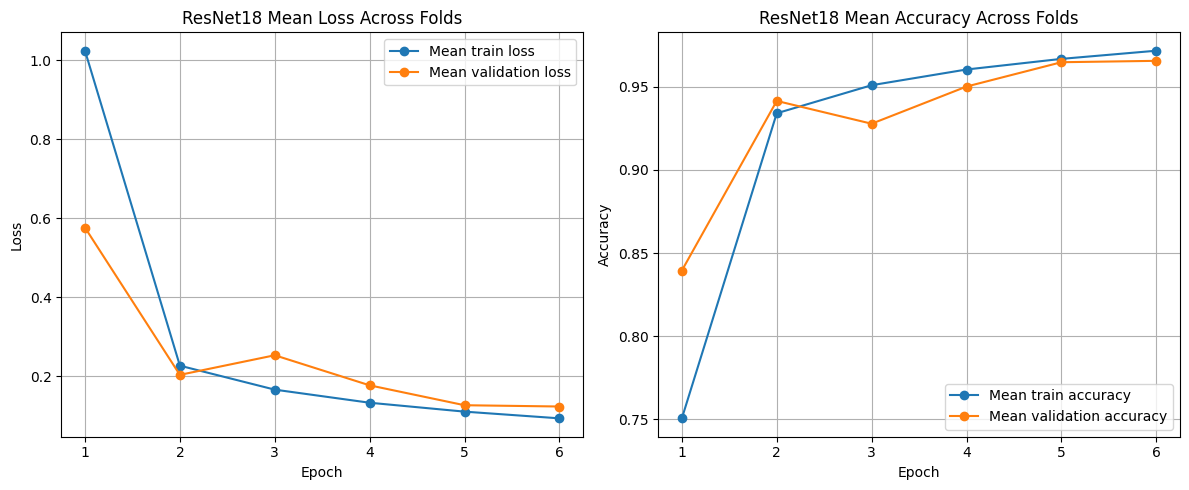

Training curves saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/figures/resnet18_training_curves.png


In [13]:
mean_history = history_df.groupby("epoch").agg({
    "train_loss": "mean",
    "validation_loss": "mean",
    "train_accuracy": "mean",
    "validation_accuracy": "mean",
    "train_f1": "mean",
    "validation_f1": "mean"
}).reset_index()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mean_history["epoch"], mean_history["train_loss"], marker="o", label="Mean train loss")
plt.plot(mean_history["epoch"], mean_history["validation_loss"], marker="o", label="Mean validation loss")
plt.title("ResNet18 Mean Loss Across Folds")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mean_history["epoch"], mean_history["train_accuracy"], marker="o", label="Mean train accuracy")
plt.plot(mean_history["epoch"], mean_history["validation_accuracy"], marker="o", label="Mean validation accuracy")
plt.title("ResNet18 Mean Accuracy Across Folds")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()

TRAINING_CURVES_PATH = FIGURES_DIR / "resnet18_training_curves.png"
plt.savefig(TRAINING_CURVES_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Training curves saved to:", TRAINING_CURVES_PATH)


## Load Best Cross-Validation Model


In [14]:
resnet18_model = create_resnet18_model(NUM_CLASSES).to(device)
resnet18_model.load_state_dict(best_overall_model_state)

print("Loaded best model from fold:", best_overall_fold)

Loaded best model from fold: 4


## Evaluate ResNet18 on Test Set


In [15]:
criterion = nn.CrossEntropyLoss()

test_loss, test_accuracy, test_f1 = evaluate_model(
    model=resnet18_model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))
print("Test macro F1-score:", round(test_f1, 4))

Test loss: 0.1559
Test accuracy: 0.9601
Test macro F1-score: 0.9604


## Save Final Summary


In [16]:
average_epoch_time = history_df["epoch_time"].mean()

summary = pd.DataFrame([{
    "model_name": "ResNet18",
    "best_fold": best_overall_fold,
    "best_validation_accuracy": best_overall_accuracy,
    "best_validation_f1": best_overall_f1,
    "mean_validation_accuracy": cv_summary_df["best_validation_accuracy"].mean(),
    "std_validation_accuracy": cv_summary_df["best_validation_accuracy"].std(),
    "mean_validation_f1": cv_summary_df["best_validation_f1"].mean(),
    "std_validation_f1": cv_summary_df["best_validation_f1"].std(),
    "test_accuracy": test_accuracy,
    "test_f1": test_f1,
    "number_of_parameters": num_parameters,
    "model_size_mb": model_size_mb,
    "total_training_time": total_training_time,
    "average_epoch_time": average_epoch_time
}])

SUMMARY_PATH = RESULTS_DIR / "resnet18_summary.csv"

summary.to_csv(SUMMARY_PATH, index=False)

print("Summary saved to:", SUMMARY_PATH)
summary

Summary saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/resnet18_summary.csv


,model_name,best_fold,best_validation_accuracy,best_validation_f1,mean_validation_accuracy,std_validation_accuracy,mean_validation_f1,std_validation_f1,test_accuracy,test_f1,number_of_parameters,model_size_mb,total_training_time,average_epoch_time
0,ResNet18,4,0.971548,0.971589,0.967141,0.002846,0.967182,0.002872,0.960123,0.960368,11293878,43.119499,14447.737077,481.511566


## Install Chinese Font for Prediction Visualization


In [17]:
# Install a font that supports Chinese characters
!apt-get -qq install fonts-noto-cjk


Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [18]:
font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
chinese_font = fm.FontProperties(fname=font_path)

plt.rcParams["axes.unicode_minus"] = False


## Visualize Random Test Predictions


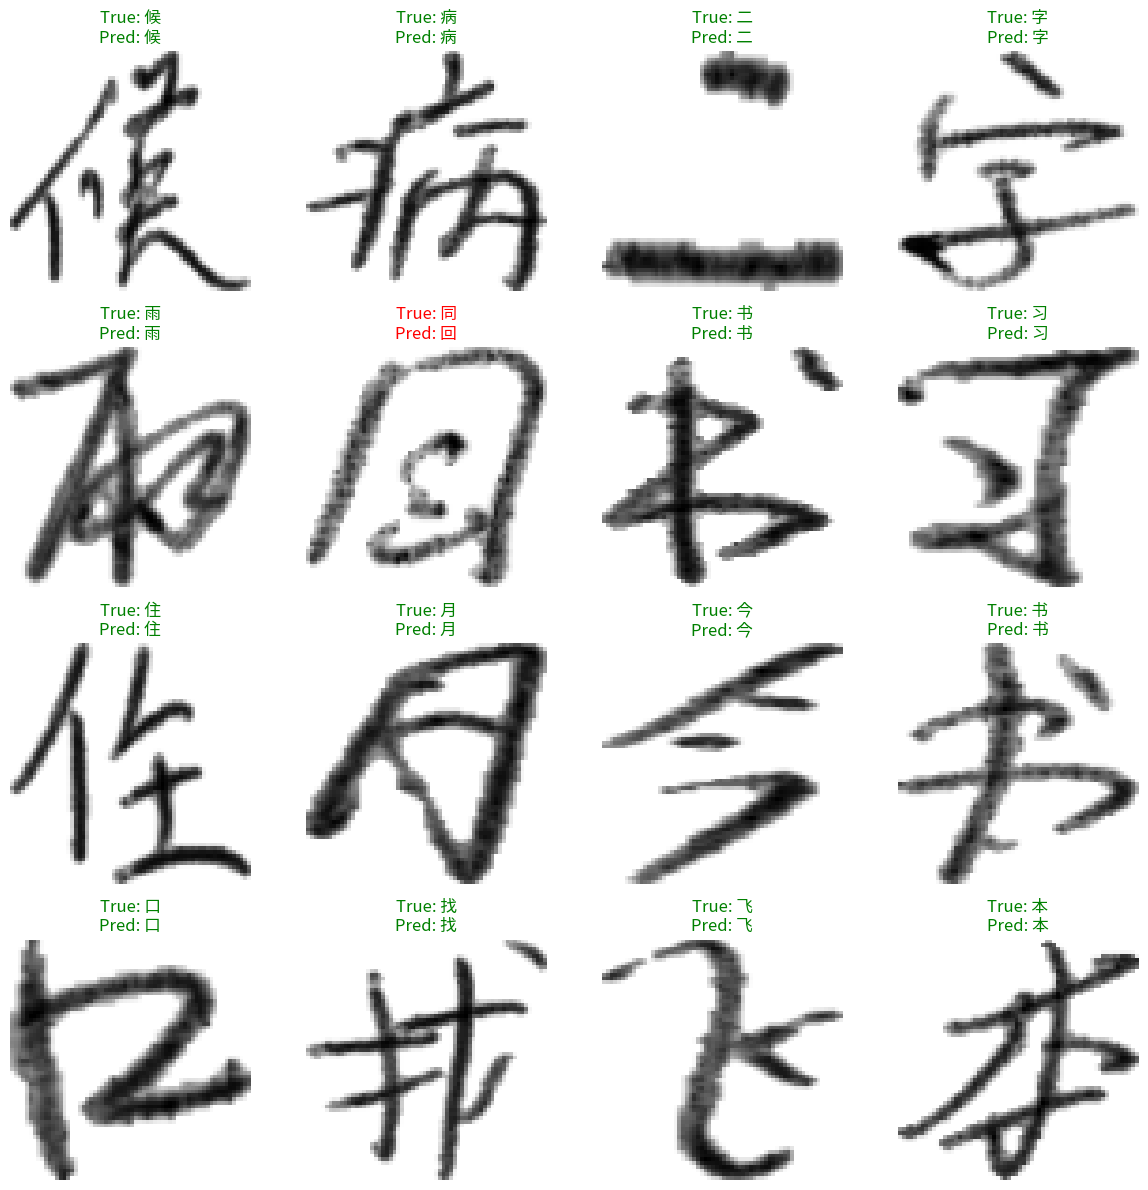

Prediction figure saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/figures/resnet18_random_test_predictions.png


In [19]:
test_labels, test_predictions = get_predictions(
    model=resnet18_model,
    data_loader=test_loader,
    device=device
)

random_indices = random.sample(range(len(test_dataset)), 16)

plt.figure(figsize=(12, 12))

for plot_index, sample_index in enumerate(random_indices):
    image, true_index = test_dataset[sample_index]

    # Convert values back to the visible range
    image = image.squeeze(0)
    image = image * 0.5 + 0.5

    predicted_index = test_predictions[sample_index].item()

    true_label = idx_to_class[true_index]
    predicted_label = idx_to_class[predicted_index]

    title_color = "green" if true_index == predicted_index else "red"

    plt.subplot(4, 4, plot_index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"True: {true_label}\nPred: {predicted_label}",
        fontproperties=chinese_font,
        fontsize=12,
        color=title_color
    )
    plt.axis("off")

plt.tight_layout()

PREDICTIONS_FIGURE_PATH = FIGURES_DIR / "resnet18_random_test_predictions.png"
plt.savefig(PREDICTIONS_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Prediction figure saved to:", PREDICTIONS_FIGURE_PATH)


The ResNet18 experiment is complete. The trained model, training history, training curves, test summary, and prediction visualization were saved to Google Drive.
